In [245]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH, RAW_DATA_PATH
from nrem_sc.utils import group_by_ids, hd_tuning

from pycircstat2.hypothesis import rayleigh_test
from pycircstat2 import Circular

import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from cmap import Colormap
from scipy.ndimage import gaussian_filter1d

cmap = Colormap("cmocean:phase")
if "cmocean:phase" not in mpl.colormaps:
    mpl.colormaps.register(cmap.to_mpl())

In [246]:
SAMPLING_RATE = 20000.0
unit_id = "107b"
spikes = {}
offset = 0

for i in range(1, 3, 1):
    # Load spike times and cluster IDs
    clu = np.load(RAW_DATA_PATH / unit_id / f"YutaTest107b.clu.{i}.npy", mmap_mode="r").squeeze()
    res = np.load(RAW_DATA_PATH / unit_id / f"YutaTest107b.res.{i}.npy", mmap_mode="r").squeeze()
    
    clu = clu[1:]  # remove number of clusters at the beginning
    units = np.unique(clu).astype(int)
    units = units[(units != 0) & (units != 1)] # exclude noise and multiunit clusters
    
    print(units)
    
    results = group_by_ids(values=res/SAMPLING_RATE, ids=clu, select_ids=units)

    for i, (key, value) in enumerate(results.items()):
        # spikes[offset+i] = {'data': nap.Ts(value), 'original_id': int(key.item())}
        spikes[offset+i] = nap.Ts(value)
    offset += len(results)

spikes = nap.TsGroup(spikes)
print(f"Total units: {len(spikes)}")

[ 16  22  32  33  34  36  38  46  53  54  56  60  64  66  70  74  78  82
  86  88  90  92  94 100 114 117 119 121 123 140 142 145 149 163 165 166
 175 176]
[ 10  12  13  17  18  27  71  76  80 110 117 121 123 131 134 136 138 140
 142 147 149 154 156 164 165 166 169 170 172 174 185 186 188 190 192 194
 196 198 200 202 208 224 226 227 229 231 233 235 237 239 249 251 253 255
 257 259 266 272 306 308 309 311 313 315 317 321 323 325 327 329 331 336
 347 349 354 355 358 360 362 363 365 367 369 371 373 375 377 379 381 383
 387 392]
Total units: 130


In [247]:
angles_rad = np.deg2rad(angle) if angle.max() > 2 * np.pi else angle
n_bins = 60

tcs = nap.compute_tuning_curves(
    data=spikes, features=angles_rad,
    bins=n_bins,
    epochs=angles_rad.time_support,
    range=(0.0, 2*np.pi),
    feature_names=['head_direction']
)

In [248]:
circ_metadata = {'kappa': [], 'skewness': [], 'kurtosis': [], 'p_value': []}
for unit_idx in range(len(tcs.unit)):
    circ = Circular(tcs[unit_idx])
    circ_metadata['kappa'].append(circ.kappa)
    circ_metadata['skewness'].append(circ.skewness)
    circ_metadata['kurtosis'].append(circ.kurtosis)
    circ_metadata['p_value'].append(rayleigh_test(alpha=tcs[unit_idx]).pval)

circ_metadata = pd.DataFrame(circ_metadata)
spikes.set_info(circ_metadata)
spikes.set_info({'pref_ang': tcs.idxmax('head_direction').values})
spikes

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\pycircstat2\descriptive.py:321: RuntimeWarning: invalid value encountered in scalar divide
  skewness = (r2 * np.sin(u2 - 2 * u1)) / (1 - r1) ** 1.5
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\pycircstat2\descriptive.py:357: RuntimeWarning: invalid value encountered in scalar divide
  kurtosis = (r2 * np.cos(u2 - 2 * u1) - r1**4) / (1 - r1) ** 2


Index    rate     kappa          skewness    kurtosis    p_value    pref_ang    ...
-------  -------  -------------  ----------  ----------  ---------  ----------  -----
0        1.6999   242.4          -2.19       -1.41       0.0        3.3         ...
1        4.90334  8.92           -5.02       5.13        0.0        3.51        ...
2        3.9164   1293.55        -0.4        -0.4        0.01       4.03        ...
3        3.81898  1423.96        -1.76       -1.11       0.0        0.16        ...
4        6.08827  1069.38        -1.87       2.11        0.0        1.94        ...
5        2.22075  1303266682.77  -13.47      5280.01     0.0        0.37        ...
6        3.54915  1099.35        0.1         -1.66       0.36       3.93        ...
...      ...      ...            ...         ...         ...        ...         ...
123      1.33592  46236.41       3.73        5.23        0.0        1.52        ...
124      1.99215  9562.93        4.12        6.04        0.0        4.66  

In [249]:
norm = plt.Normalize(0, 2*np.pi)
colors = cmap(norm(spikes['pref_ang'].values))
colors.shape

(130, 4)

In [250]:
tcs_smooth = gaussian_filter1d(tcs.values, sigma=3, axis=1, mode="wrap")

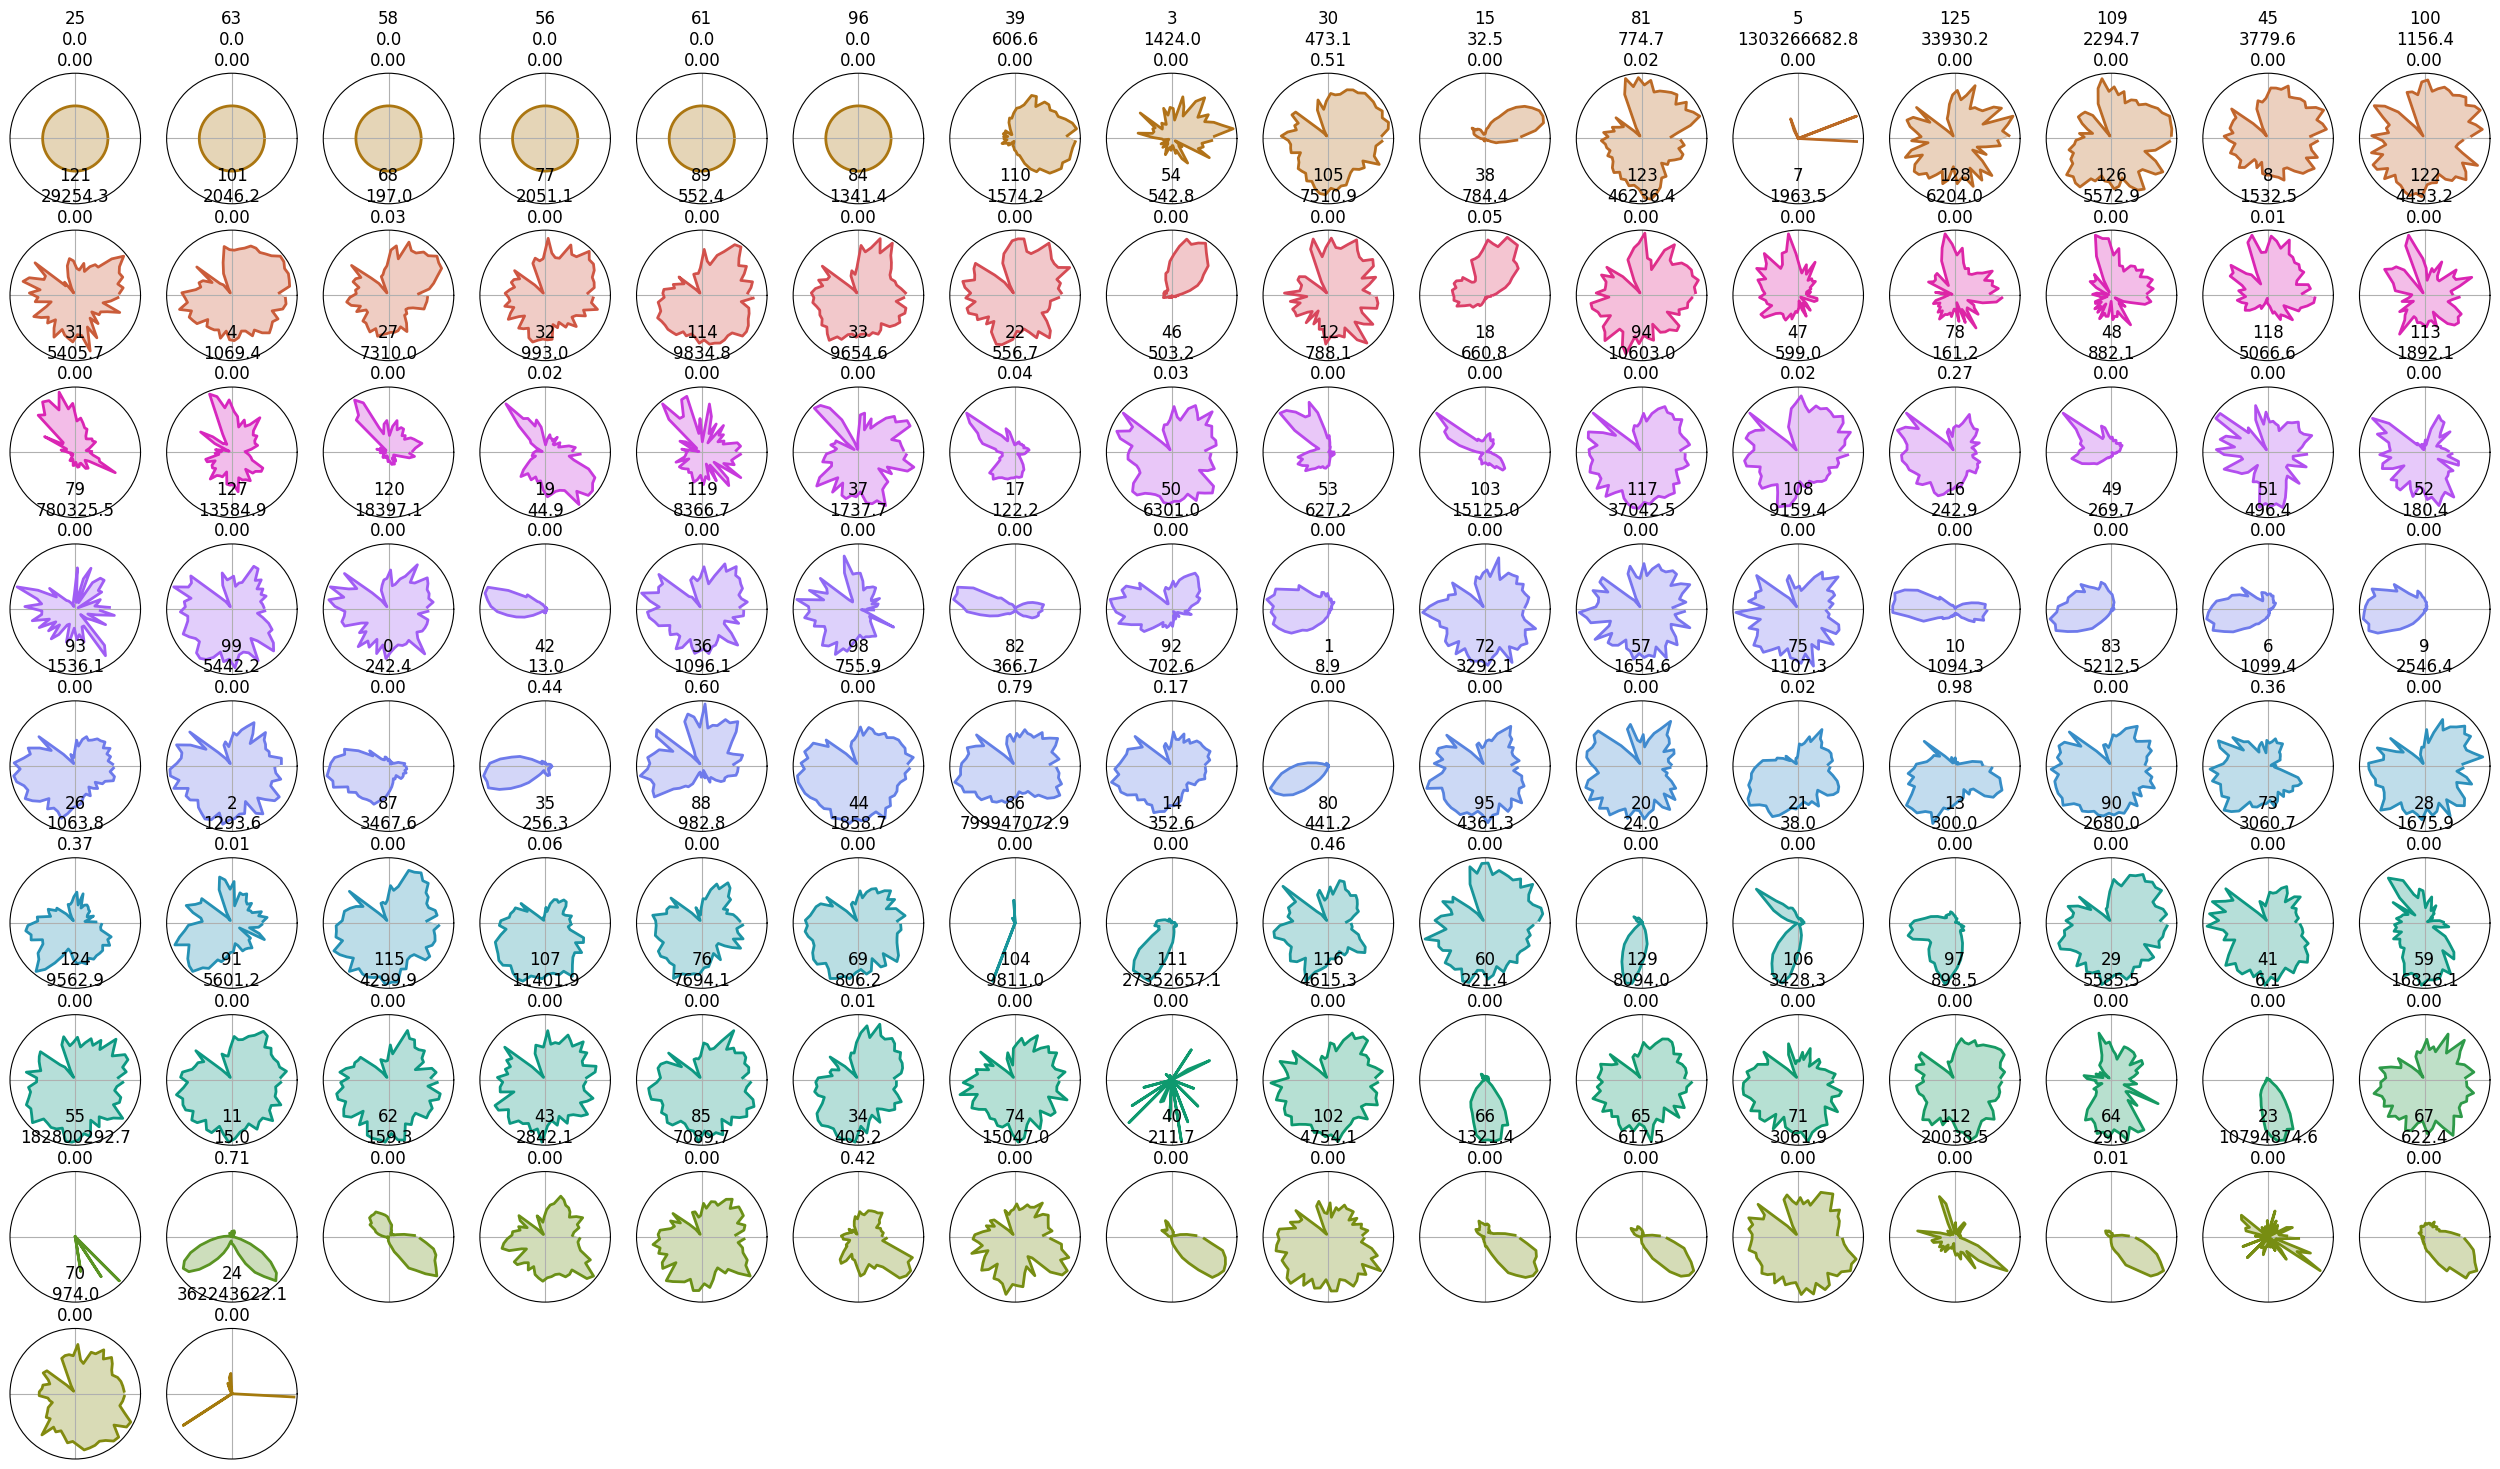

In [251]:
sorted_idx = np.argsort(tcs.idxmax('head_direction').values)
n_units = len(spikes)

angles = tcs["head_direction"]    
ncols = 16
nrows = n_units // ncols + 1
figsize = (ncols*2, nrows*2)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, subplot_kw={'projection': 'polar'})
axes = axes.flatten()

for ax in axes:
    ax.set_visible(False)

for i, n in enumerate(sorted_idx):
    axes[i].plot(angles, tcs[n], linewidth=2, color=colors[n])
    axes[i].fill(angles, tcs[n], color=colors[n], alpha=0.3)

    axes[i].set_visible(True)
    axes[i].set_yticks([])
    axes[i].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    axes[i].set_xticklabels([])
    axes[i].set_title(f"{n}\n{circ_metadata.loc[n]['kappa']:.1f}\n{circ_metadata.loc[n]['p_value']:.2f}", fontsize=12)

39


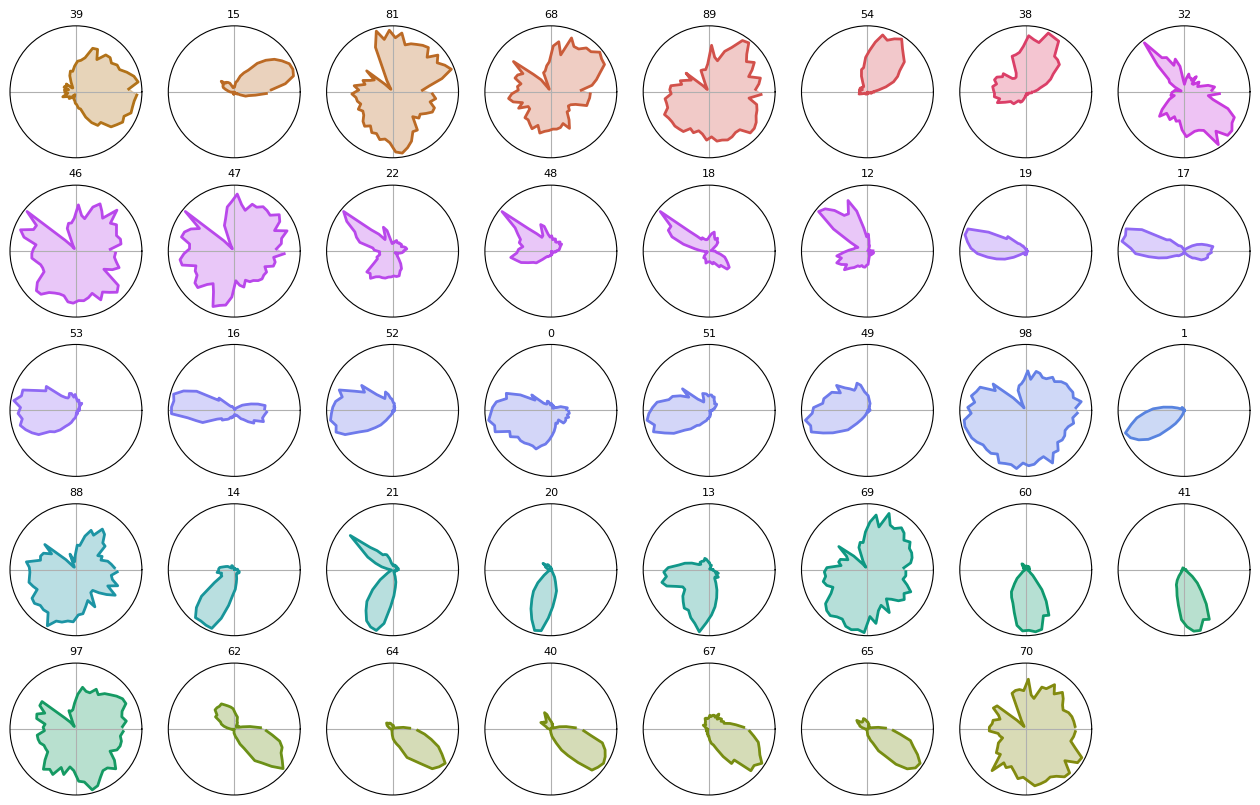

In [254]:
hd_spikes = spikes[(spikes['kappa'] < 1000) & (spikes['p_value'] < 0.05) & (~spikes['kurtosis'].isna())]
print(len(hd_spikes))
angles = tcs.coords["head_direction"]

sorted_idx = hd_spikes.index[np.argsort(hd_spikes['pref_ang'].values)]
n_units = len(hd_spikes)

ncols = 8
nrows = n_units // ncols + 1
figsize = (ncols*2, nrows*2)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, subplot_kw={'projection': 'polar'})
axes = axes.flatten()

for ax in axes:
    ax.set_visible(False)

for i, n in enumerate(sorted_idx):
    axes[i].plot(angles, tcs.sel(unit=n).values, linewidth=2, color=colors[n])
    axes[i].fill(angles, tcs.sel(unit=n).values, color=colors[n], alpha=0.3)

    axes[i].set_visible(True)
    axes[i].set_yticks([])
    axes[i].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    axes[i].set_xticklabels([])
    axes[i].set_title(f"{n}", fontsize=8)


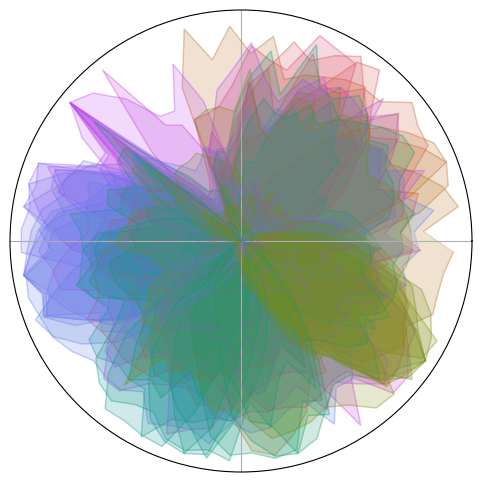

In [253]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})

for n in sorted_idx:
    norm = plt.Normalize()
    ax.plot(angles, norm(tcs[n]), linewidth=1, color=colors[n], alpha=0.2)
    ax.fill(angles, norm(tcs[n]), color=colors[n], alpha=0.2)
    ax.set_yticks([])
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    ax.set_xticklabels([])


In [ ]:
hd_spikes.drop_info(['kappa', 'skewness', 'kurtosis', 'p_value'])
hd_spikes.save(PROCESSED_DATA_PATH / unit_id / "hd_spikes")

Index    rate     pref_ang
-------  -------  ----------
0        1.6999   3.3
1        4.90334  3.51
12       2.0094   2.46
13       1.57556  4.56
14       1.08584  4.35
15       2.46556  0.37
16       1.79704  3.19
...      ...      ...
69       4.10798  4.66
70       5.23736  5.81
81       3.90722  0.37
88       4.33068  4.24
89       7.11533  0.89
97       4.89686  4.97
98       2.02173  3.4